<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Ftrabalho-02/trabalho-02/demoD4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from typing import NewType, List
import numpy as np
import matplotlib.pyplot as plt
import math
import statistics

# Tipo para representar cada ponto: um registro com features float
Point = NewType("Point", tuple[float, ...])

def dist(p: Point, q: Point) -> float:
  soma = 0
  for i in range(len(p)):
      # Calcula a diferença para cada feature
      soma += (p[i] - q[i]) ** 2

  return math.sqrt(soma)


def normalizacao(x: np.ndarray) -> np.ndarray:
  # Pegar os valores mínimos e máximos de cada feature
  mins = np.min(x, axis=0)
  maxs = np.max(x, axis=0)

  denom = maxs - mins # max(xi) - min(xi)
  denom[denom == 0] = 1

  return mins, denom

def aplicaNormalizacao(x: np.ndarray, mins: np.ndarray, denom: np.ndarray) -> np.ndarray:
  return (x - mins) / denom

def getDadosRotulo(dados: np.ndarray, rotulos: np.ndarray, rotulo: int, indice: int) -> List[int]:
    ret = []
    for idx in range(0, len(dados)):
        if(rotulos[idx] == rotulo):
            ret.append(dados[idx][indice])
    return ret

def visualizaPontos(dados: np.ndarray, rotulos: np.ndarray, d1: int, d2: int):
    fig, ax = plt.subplots()

    ax.scatter(getDadosRotulo(dados, rotulos, 1, d1), getDadosRotulo(dados, rotulos, 1, d2), c='red' , marker='^')
    ax.scatter(getDadosRotulo(dados, rotulos, 2, d1), getDadosRotulo(dados, rotulos, 2, d2), c='blue' , marker='+')
    ax.scatter(getDadosRotulo(dados, rotulos, 3, d1), getDadosRotulo(dados, rotulos, 3, d2), c='green', marker='.')

    plt.show()

def meuKnn(dadosTrain: np.ndarray, rotuloTrain: List[List[int]], dadosTeste: np.ndarray, k: int) -> np.ndarray:
  # Cria matriz de distâncias com dimensão nº de linhas de teste X nº de linhas de treino
  distances = np.ndarray(shape=(dadosTeste.shape[0], dadosTrain.shape[0]))
  predictions = np.zeros(shape=(dadosTeste.shape[0]))

  for row in range(dadosTeste.shape[0]):
    for col in range(dadosTrain.shape[0]):
      distances[row, col] = dist(dadosTeste[row], dadosTrain[col])

    # Armazena (distancia, rotulo) para todos os vizinhos
    closest_neighbors = [
        (v, rotuloTrain[i][0])
        for i, v in enumerate(distances[row])
    ]

    # Ordena os vizinhos pelo valor da distância
    closest_neighbors.sort(key=lambda x: x[0])

    # Mantém apenas os K vizinhos mais próximos
    predictions[row] = statistics.mode(
        [rot for (_, rot) in closest_neighbors[:k]]
    )

  return predictions


def calculaAcuracia(predicted_labels, test_labels):
  is_correct = [1 for i in range(len(test_labels)) if test_labels[i] == predicted_labels[i]]
  correct_total = sum(is_correct)
  total = len(test_labels)

  accuracy = correct_total / total
  return accuracy

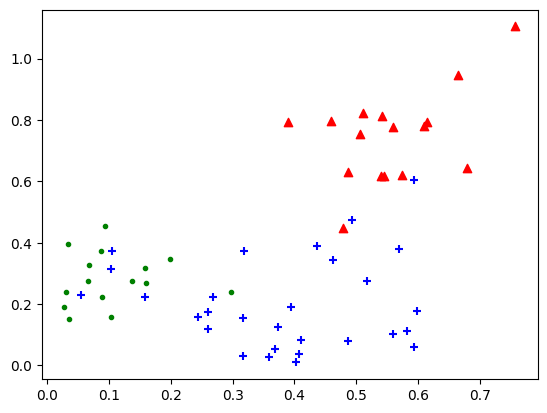

Acurácia: 0.7833333333333333


In [24]:
from scipy.io import loadmat

# Lê o dataset
data = loadmat('grupoDados4.mat')

# Faz escala contando com treino e teste
min_vals, denom = normalizacao(data['trainSet'])

# Ajusta os valores ao filtro normalizado
test_set = aplicaNormalizacao(data['testSet'], min_vals, denom)
train_set = aplicaNormalizacao(data['trainSet'], min_vals, denom)

train_labels = data['trainLabs']
test_labels = data['testLabs']

# Retorna previsão de rótulo para cada dado de teste
predicted_labels = meuKnn(train_set, train_labels, test_set, 1)

# Plota rótulos da previsão no gráfico
visualizaPontos(test_set, predicted_labels, 0, 1)

# Calcula acurácia da previsão
accuracy = calculaAcuracia(predicted_labels, test_labels)
print(f"Acurácia: {accuracy}")

### 1: Aplique seu algoritmo K-NN ao problema. Qual é a sua acurácia de classificação?
---
A acurácia é de 78%.

### 2. A acurácia pode chegar a 92% com o K-NN. Descubra por que o resultado atual é muito menor. Ajuste o conjunto de dados ou o valor de k de forma que a acurácia atinja 92% e explique o que você fez e por quê. Observe que, desta vez, há mais de um problema...
---
Primeiramente, observou-se que somente ajustar o valor de k não resultou em aumento significativo da acurácia. Para k = 1, a acurácia foi de 78%, e para k = 9, 82%. Isso sugere que apenas considerar mais vizinhos não é suficiente para ter resultados satisfatórios em relação ao dataset.


In [4]:
k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Testando para os valores de k entre 1 e 10
for k in k_values:
    predicted_labels_k = meuKnn(train_set, train_labels, test_set, k)
    accuracy = calculaAcuracia(predicted_labels_k, test_labels)

    print(f'Acurácia para k = {k} -> {accuracy}')

Acurácia para k = 1 -> 0.7833333333333333
Acurácia para k = 2 -> 0.7833333333333333
Acurácia para k = 3 -> 0.8
Acurácia para k = 4 -> 0.8333333333333334
Acurácia para k = 5 -> 0.8333333333333334
Acurácia para k = 6 -> 0.8166666666666667
Acurácia para k = 7 -> 0.8
Acurácia para k = 8 -> 0.8
Acurácia para k = 9 -> 0.8166666666666667
Acurácia para k = 10 -> 0.8


In [5]:
import numpy as np

"""
Encontra todos os pontos cuja previsão é diferente do y^ esperado,
ordenando-os pelo score de distância.
"""
def find_noise_points(X, y, k=3):
    suspects = []

    y = y.ravel()
    for i in range(len(X)):
        x = X[i]

        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i, axis=0)

        dists = np.linalg.norm(X_train - x, axis=1)

        idx = np.argsort(dists)[:k]

        neighbors_labels = y_train[idx].ravel()
        neighbors_dist = dists[idx]

        pred = np.bincount(neighbors_labels.astype(int)).argmax()

        if pred != y[i]:
            score = np.mean(neighbors_dist)
            suspects.append((i, x, y[i], pred, score))

    return sorted(suspects, key=lambda x: x[4], reverse=True)

Index 80 | Real: 2 | Pred: 1 | Score: 0.5629518041569413
Index 49 | Real: 2 | Pred: 1 | Score: 0.35764214206307127
Index 97 | Real: 3 | Pred: 2 | Score: 0.3056876092513379
Index 101 | Real: 3 | Pred: 2 | Score: 0.3042675425806359
Index 90 | Real: 3 | Pred: 2 | Score: 0.29456261319603644
Index 46 | Real: 2 | Pred: 3 | Score: 0.2798317933942462
Index 39 | Real: 2 | Pred: 3 | Score: 0.2705781565528257
Index 78 | Real: 2 | Pred: 3 | Score: 0.2687974928379995
Index 91 | Real: 3 | Pred: 2 | Score: 0.26492182259890595
Index 63 | Real: 2 | Pred: 1 | Score: 0.2625136580654724


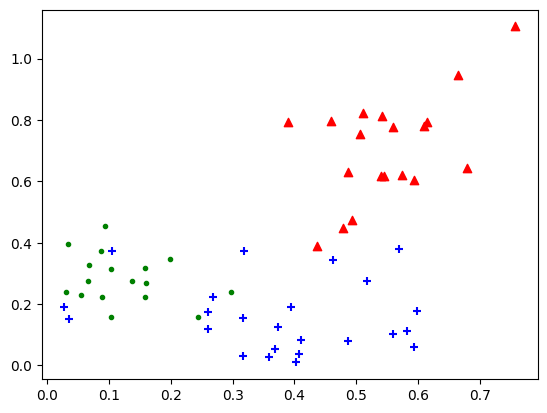

Acurácia: 0.8333333333333334


In [44]:
suspects = find_noise_points(train_set, train_labels, 7)

suspect_indexes = []
for i, x, real, pred, score in suspects[:10]:
    suspect_indexes.append(i)
    print(f"Index {i} | Real: {real} | Pred: {pred} | Score: {score}")

mask = np.ones(len(train_set), dtype=bool)
mask[suspect_indexes] = False

set_cleaned = train_set[mask]
labels_cleaned = train_labels[mask]

predicted_labels = meuKnn(set_cleaned, labels_cleaned, test_set, 7)

visualizaPontos(test_set, predicted_labels, 0, 1)

accuracy = calculaAcuracia(predicted_labels, test_labels)
print(f"Acurácia: {accuracy}")